# **pyNamo-EGT release figures**

Prepare two images for the release announcement: a rock–paper–scissors phase portrait and a four-strategy 3D portrait. Run this notebook from the repository root using an environment where pyNamo-EGT is installed.

The default previews are static Retina PNGs. Exports use a white background and include a 300 dpi PNG for sharing, plus SVG and PDF versions. No files are exported until you run the export cells.

All figure text is rendered with LaTeX using serif fonts. Run this notebook locally with LaTeX and Matplotlib's rendering helpers installed; the notebook kernel must be able to find them on its PATH. Rerun setup and the plotting cells after changing text settings.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pynamo_egt as pn

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

output_dir = Path("release_figures")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 13,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

## 1. Rock–paper–scissors

Use this as the opening image. The colored speed field and inward trajectories show the dynamics at a glance. Adjust `figsize`, label size, and trajectory width below if needed; check readability at phone size before sharing.

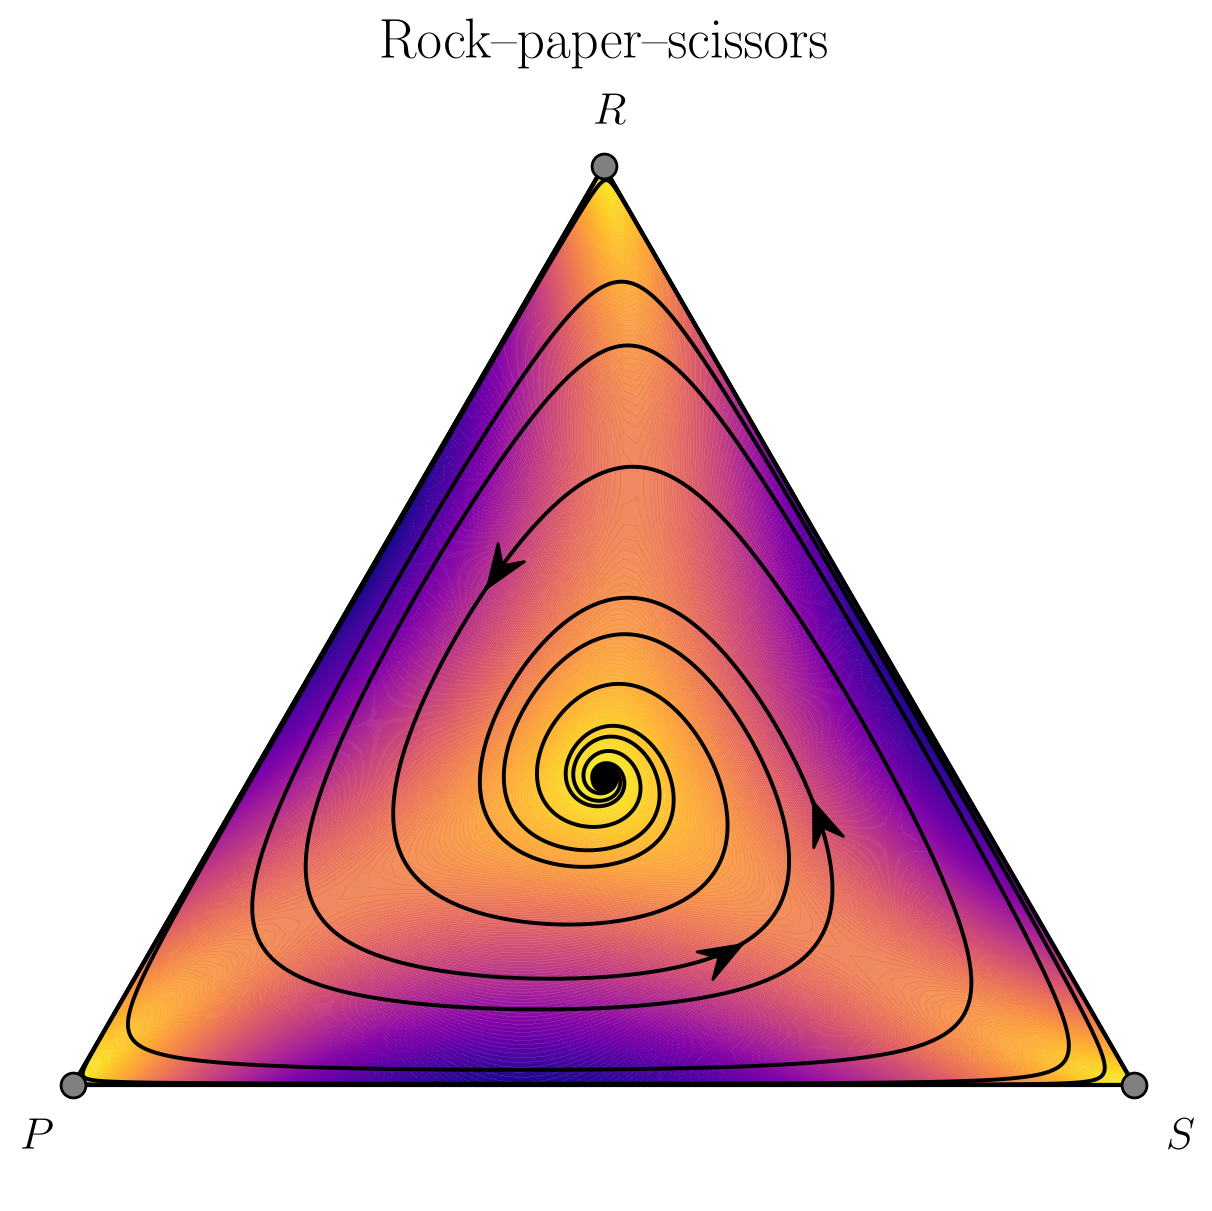

In [15]:
%matplotlib inline
plt.close("all")

rps_fig, rps_ax = pn.phase_portrait(
    game=pn.examples.games.good_rps,
    figsize=(8, 7),
    starts=[        [0.3, 0.15],
        [0.15, 0.3],
        [0.55, 0.33]
    ],
    tmax=30,
    trajectory_step=0.02,
    trajectory_color="black",
    trajectory_linewidth=1.4,
    trajectory_arrows=[0.001],
    show_speed=True,
    speed_cmap=plt.cm.plasma_r,
    speed_grid=80,
    speed_levels=200,
    simplex_font_size=16,
    equilibrium_size=80,
)
rps_ax.set_title("Rock--paper--scissors", fontsize=20, pad=20)
plt.show()

## 2. Four-strategy dynamics

Three gray faces and one transparent face frame the colored trajectories. The vector field is omitted to keep this promotional image readable.

For rotation, change `%matplotlib inline` in the next cell to `%matplotlib widget`, then rerun it. Rotate to your preferred view before exporting; the export uses the current view. Widgets require the notebook extras and may occasionally appear blank in Binder. Rerunning the cell or switching back to inline gives another way to preview it.

/Users/slimane/Documents/GitHub/pyNamo/pynamo_egt/drawer.py:1215: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


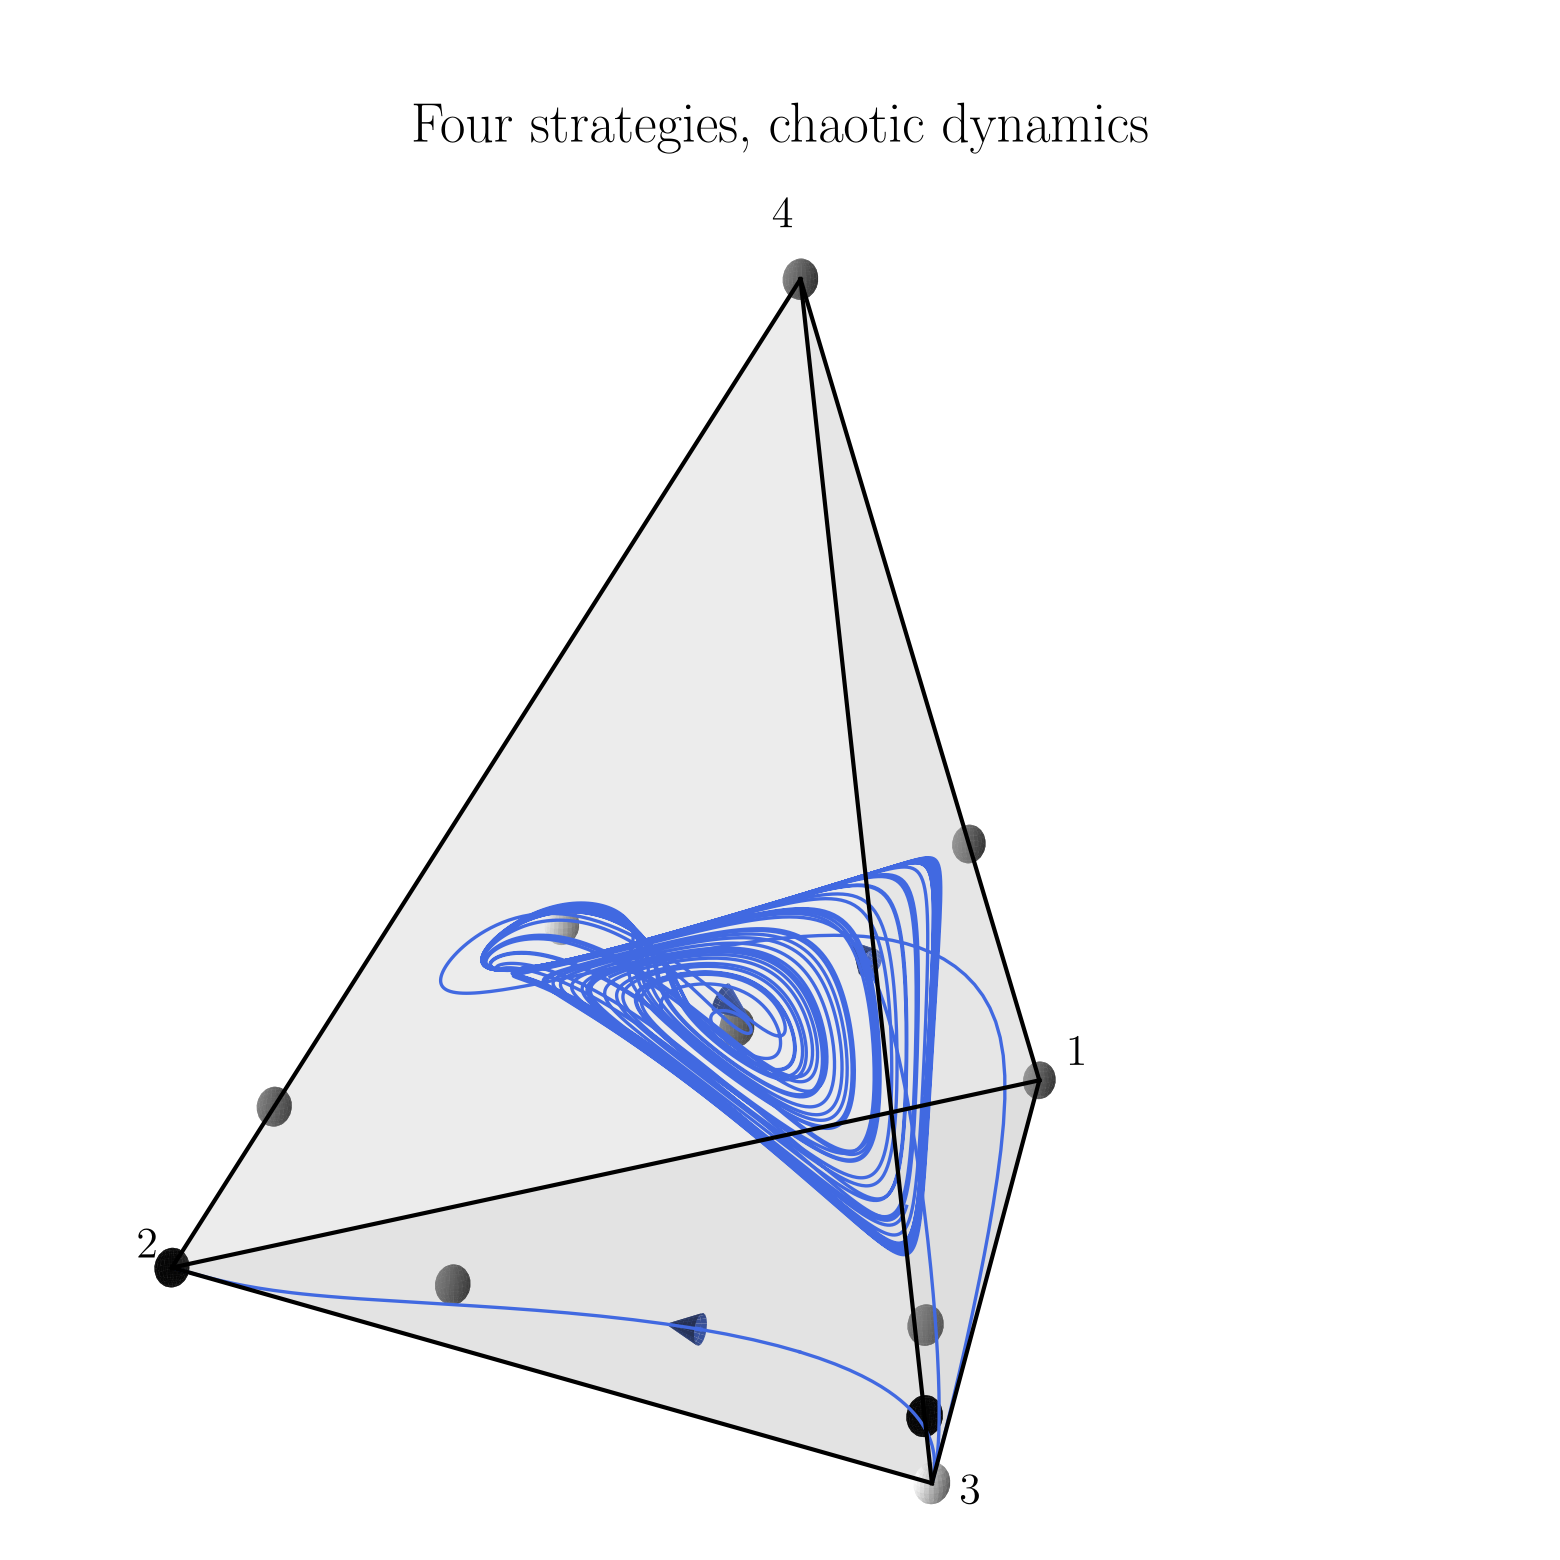

In [35]:
%matplotlib inline
plt.close("all")

chaos_fig, chaos_ax = pn.phase_portrait(
    game=pn.examples.games.chaotic_four_strategy_game,
    figsize=(8, 8),
    view_elev=20,
    view_azim=-56,
    starts=[[0.22, 0.25, 0.25], [0.20, 0.20, 0.60], [0.45, 0.10, 0.20]],
    tmax=90,
    trajectory_step=0.02,
    trajectory_color="royalblue",
    trajectory_linewidth=1.2,
    trajectory_arrows=[0.001],
    show_speed=False,
    show_vector_field=False,
    show_faces=True,
    face_colors=["#666666", "#999999", "#CCCCCC", "none"],
    face_alpha=0.18,
    simplex_font_size=16,
    equilibrium_size=30,
    equilibrium_edgecolor="black",
)
chaos_ax.set_title(
    "Four strategies, chaotic dynamics",
    fontsize=20,
    y=1,
    pad=0,
)
chaos_ax.set_box_aspect((1, 1, 1), zoom=1.2)
chaos_fig.subplots_adjust(
    left=0.02, right=0.98,
    bottom=0.03, top=0.98,
)
plt.show()

## 3. Asymmetric 3-player game

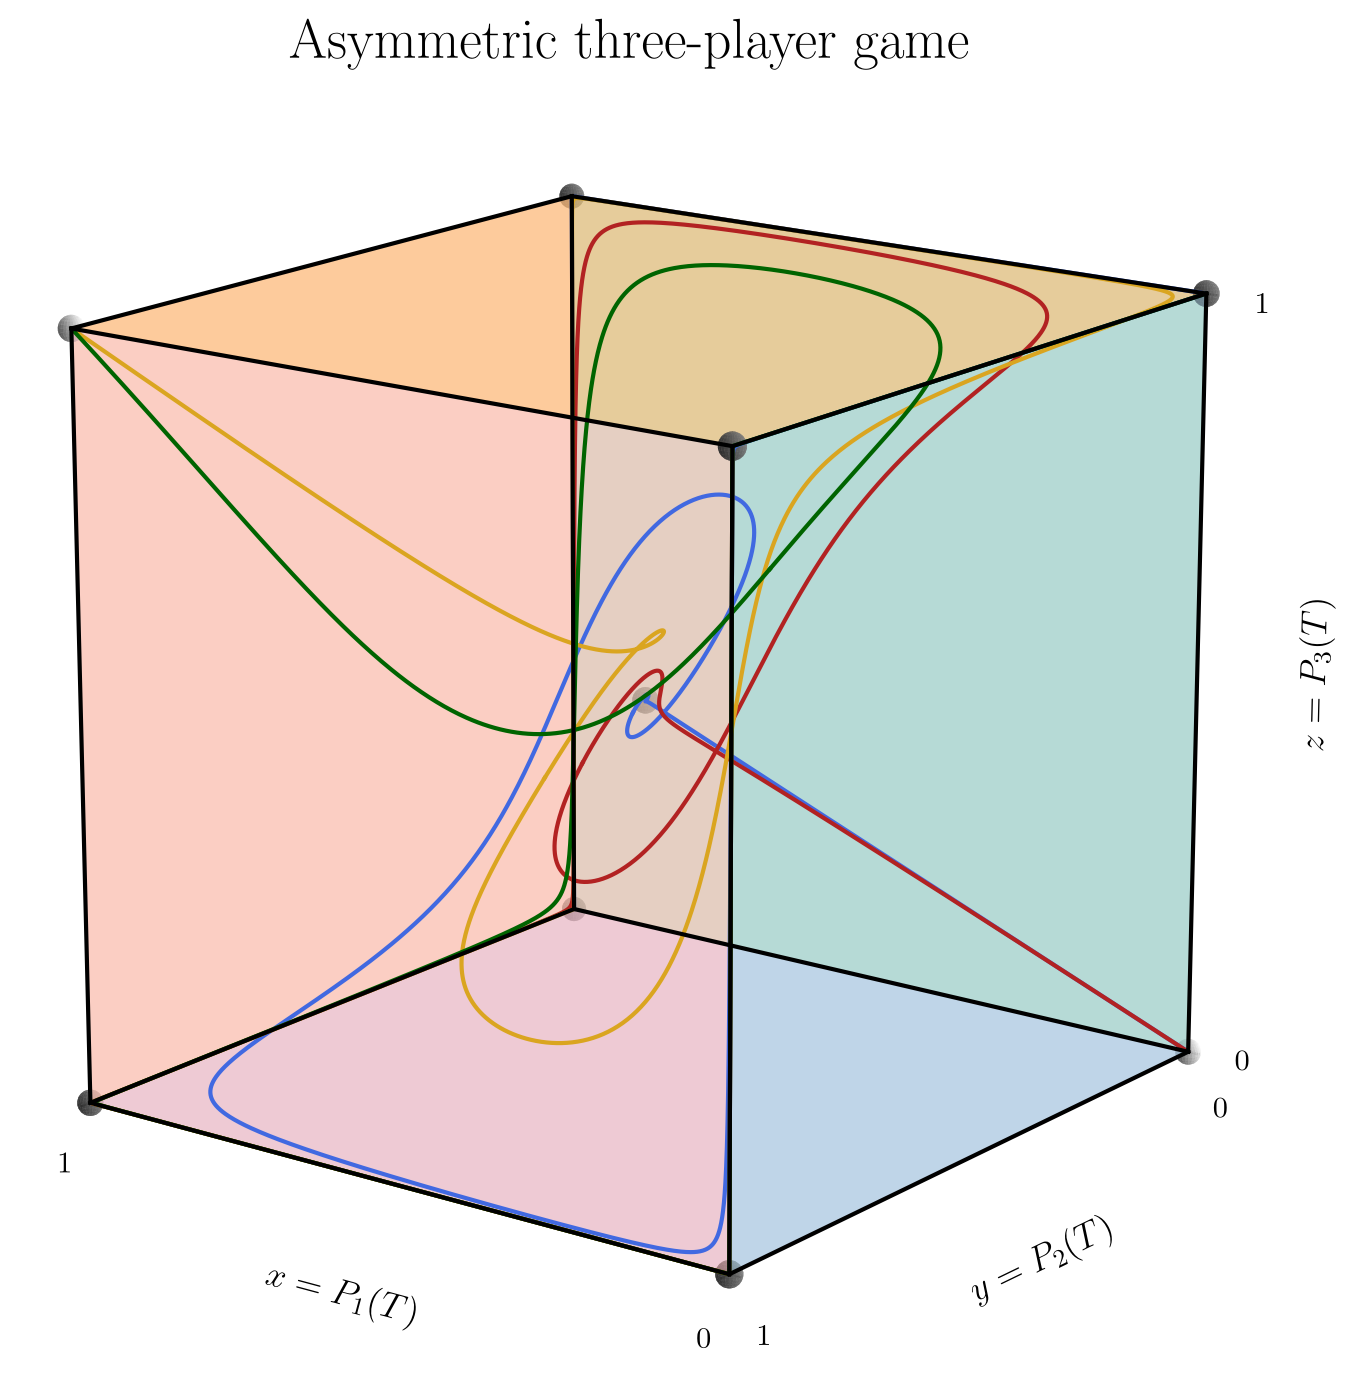

In [37]:
%matplotlib inline
plt.close("all")

cube_fig, cube_ax = pn.phase_portrait(
    game=pn.examples.games.cyclic_mismatching_pennies,
    figsize=(8, 7),
    view_elev=16,
    view_azim=127,
    show_faces=True,
    face_alpha=0.5,
    starts=[
        [0.52, 0.50, 0.48],
        [0.60, 0.50, 0.40],
        [0.70, 0.45, 0.35],
        [0.20, 0.65, 0.75],
    ],
    tmax=400,
    trajectory_arrows=[],
    trajectory_color=["royalblue", "firebrick", "goldenrod", "darkgreen"],
    trajectory_linewidth=1.5,
    equilibrium_size=25,
)
cube_ax.set_title("Asymmetric three-player game", fontsize=20, pad=18)
cube_ax.set_box_aspect((1, 1, 1), zoom=1.1)
cube_fig.subplots_adjust(left=0.03, right=0.97, bottom=0.03, top=0.90)
plt.show()

## 4. Hawk-Dove game

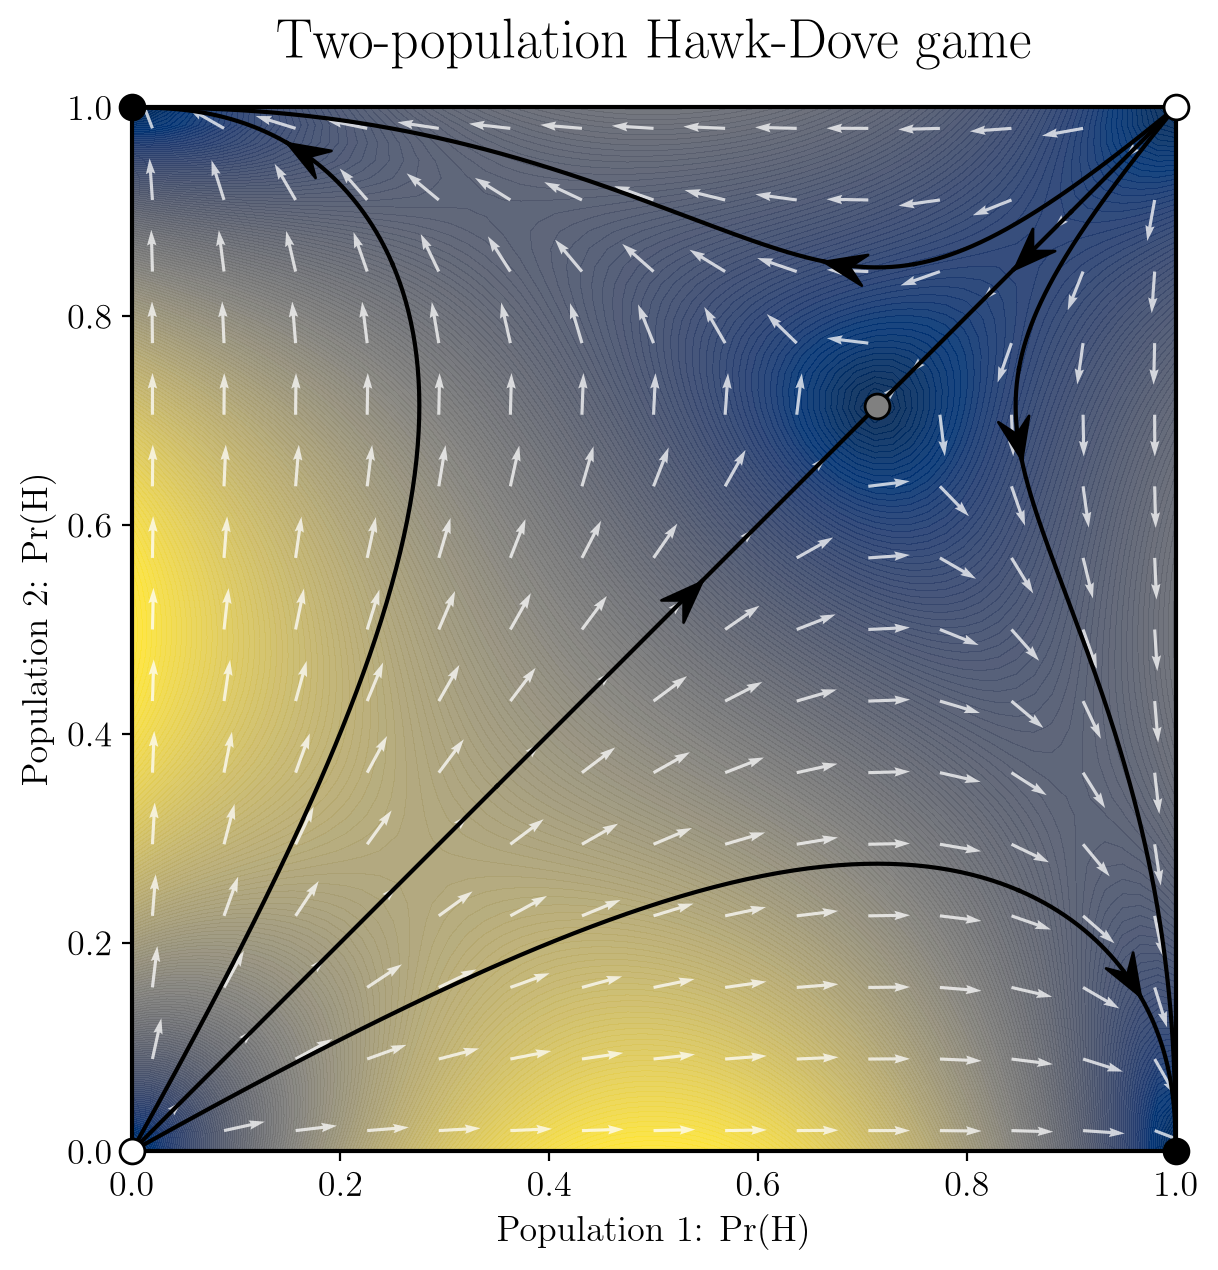

In [36]:
%matplotlib inline
plt.close("all")

hawk_dove_fig, hawk_dove_ax = pn.phase_portrait(
    game=pn.examples.games.two_population_hawk_dove,
    starts=[
        [0.25, 0.85],
        [0.35, 0.35],
        [0.9, 0.9],
        [0.85, 0.25],
        [0.85, 0.75],
        [0.75, 0.85]
    ],
    show_speed=True,
    speed_levels=200,
    show_vector_field=True,
    vector_color="white",
    speed_cmap=plt.cm.cividis,
    trajectory_linewidth=1.5,
)
hawk_dove_ax.set_title("Two-population Hawk-Dove game", fontsize=20, pad=18)
hawk_dove_fig.subplots_adjust(left=0.03, right=0.97, bottom=0.03, top=0.90)
plt.show()

## 5. Export

Run this after preparing both figures. Each run creates a new numbered filename for an image if an earlier export exists, so previous exports are preserved. PNG resolution is independent of the notebook preview; SVG/PDF preserve vector elements.

Inspect the exported PNGs for readable labels, clipped edges, and visible trajectories. Use the RPS image first and the 3D image second in the post. A screenshot of the tutorial explorer can be an optional third image.

In [38]:
def export_figure(fig, stem):
    output_dir.mkdir(exist_ok=True)
    suffixes = ("png", "svg", "pdf")
    version = 1
    candidate = stem
    while any((output_dir / f"{candidate}.{ext}").exists() for ext in suffixes):
        version += 1
        candidate = f"{stem}_{version}"
    for ext in suffixes:
        path = output_dir / f"{candidate}.{ext}"
        fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.2, facecolor="white")
        print(path)

export_figure(rps_fig, "pynamo_egt_rps")
export_figure(chaos_fig, "pynamo_egt_four_strategy")
export_figure(cube_fig, "pynamo_egt_cyclic_mismatching_pennies")
export_figure(hawk_dove_fig, "pynamo_egt_hawk_dove")

release_figures/pynamo_egt_rps.png
release_figures/pynamo_egt_rps.svg
release_figures/pynamo_egt_rps.pdf
release_figures/pynamo_egt_four_strategy.png
release_figures/pynamo_egt_four_strategy.svg
release_figures/pynamo_egt_four_strategy.pdf
release_figures/pynamo_egt_cyclic_mismatching_pennies.png
release_figures/pynamo_egt_cyclic_mismatching_pennies.svg
release_figures/pynamo_egt_cyclic_mismatching_pennies.pdf
release_figures/pynamo_egt_hawk_dove.png
release_figures/pynamo_egt_hawk_dove.svg
release_figures/pynamo_egt_hawk_dove.pdf
